In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split



In [ ]:
# cargamos los embeddings generados previamente
X_train = np.load("../data/processed/Elmo/X_train_elmo_mean.npy")
X_test  = np.load("../data/processed/Elmo/X_test_elmo_mean.npy")

# cargamos las etiquetas con el mismo split que usamos al generar los embeddings
df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 1024), X_test: (1032, 1024)
y_train: (4126,), y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 1, 128)         │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,032 (597.78 KB)

 Trainable params: 153,032 (597.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3345 - loss: 1.3582 - val_accuracy: 0.3269 - val_loss: 1.3343
Epoch 2/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3253 - loss: 1.3251 - val_accuracy: 0.3269 - val_loss: 1.3137
Epoch 3/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3272 - loss: 1.3160 - val_accuracy: 0.3269 - val_loss: 1.3098
Epoch 4/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3299 - loss: 1.3158 - val_accuracy: 0.3269 - val_loss: 1.3085
Epoch 5/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3194 - loss: 1.3177 - val_accuracy: 0.3269 - val_loss: 1.3075
Epoch 6/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3315 - loss: 1.3136 - val_accuracy: 0.3269 - val_loss: 1.3060
Epoch 7/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3253 - loss: 1.3115 - val_accuracy: 0.3269 - val_loss: 1.3058
Epoch 8/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3353 - loss: 1.3116 - val_accu

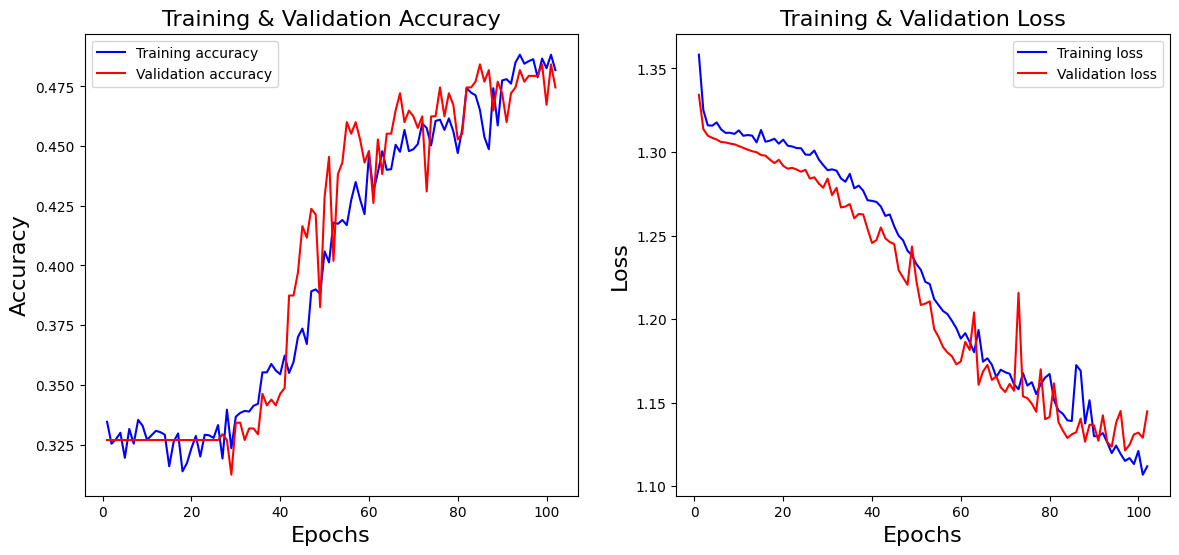

In [10]:
# la CNN espera entrada 3D (batch, steps, features)
# reshape de (n_muestras, 768) -> (n_muestras, 1, 768)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

# definimos el modelo
model = Sequential()
model.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=64, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(num_clases, activation='softmax'))  # una neurona por clase
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_clases, activation='softmax'))


model.summary()
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

# curvas de aprendizaje
history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()